In [1]:
import os

In [2]:
username = os.environ.get("USER") or os.environ.get("USERNAME")
if username:
    print(f"Username: {username}")
else:
    print("Username not found in environment variables.")
    sys.exit()

Username: yun79


In [3]:
from pathlib import Path
cwd = str(Path.cwd())
print(f"PWD: {cwd}")
os.environ["PYTHONPATH"] += f":{cwd}"
os.environ["X509_USER_PROXY"] = f"{cwd}/voms_proxy.txt"
os.environ['XRD_REQUESTTIMEOUT'] = "2400"
!echo $PYTHONPATH

PWD: /work/users/yun79/Run3/copperheadV2
/depot/cms/kernels/coffea_latest/bin:/work/users/yun79/Run3/copperheadV2


In [4]:
from dask_gateway import Gateway
# gateway = Gateway()
gateway = Gateway(
    "http://dask-gateway-k8s.geddes.rcac.purdue.edu/",
    proxy_address="traefik-dask-gateway-k8s.cms.geddes.rcac.purdue.edu:8786",
)

In [5]:
for cluster_info in gateway.list_clusters():
    print(cluster_info)

In [6]:
cluster = gateway.new_cluster(
    # conda_env = "/depot/cms/kernels/coffea2024",
    # conda_env = "/depot/cms/kernels/root632",
    # conda_env = "/depot/cms/kernels/coffea_latest",
    # conda_env = "/work/kernels/coffea_dask/",
    conda_env = "/depot/cms/users/yun79/conda_envs/yun_coffea_latest",
    worker_cores = 2, #2
    worker_memory = 6, #10
    env = dict(os.environ),
)

cluster.adapt(minimum=15, maximum=499) # 399 for low resources, otherwise 199
cluster
# cluster.adapt(100) 

/depot/cms/kernels/coffea_latest/lib/python3.12/site-packages/dask_gateway/client.py:702: GatewayWarning: Adapt with `maximum=499, minimum=15` workers would exceed resource limit of 199 workers. Using `maximum=199, minimum=15` instead.
  warnings.warn(GatewayWarning(msg["msg"]))


In [20]:
for cluster_info in gateway.list_clusters():
    print(cluster_info)

ClusterReport<name=cms.3c913f5dfcef41b88c9e5448189ae1ff, status=RUNNING>


In [21]:
"""
To shutdown the cluster, run this cell
Equivalently, you can also do "squeue -u <username>" 
if this is the only slurm job you're doing
"""

for cluster_info in gateway.list_clusters():
    gateway.connect(cluster_info.name).shutdown()

In [22]:
for cluster_info in gateway.list_clusters():
    print(cluster_info)

In [ ]:
options = gateway.cluster_options()  

In [ ]:
# options.worker_cores
print(options)

In [ ]:
! squeue -u shar1172

In [11]:
import numpy as np

# np.linspace(0,600,51).tolist()
np.linspace(0,600,61).tolist()

array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 210.,
       220., 230., 240., 250., 260., 270., 280., 290., 300., 310., 320.,
       330., 340., 350., 360., 370., 380., 390., 400., 410., 420., 430.,
       440., 450., 460., 470., 480., 490., 500., 510., 520., 530., 540.,
       550., 560., 570., 580., 590., 600.])

In [12]:
import ROOT
import array

# Custom bin edges (must be sorted and increasing)
bin_edges = [0.0, 1.0, 2.5, 3.0, 5.0, 10.0]

# Convert to C-style array (array of doubles)
edges_array = array.array('d', bin_edges)

# Number of bins = len(bin_edges) - 1
hist = ROOT.TH1D("hist", "Custom Bin Edges", len(bin_edges) - 1, edges_array)

# Optionally fill it
hist.Fill(0.5)
hist.Fill(2.0)
hist.Fill(6.0)

# Draw if needed
c = ROOT.TCanvas()
hist.Draw()
c.SaveAs("custom_bins_hist.png")


Info in <TCanvas::Print>: png file custom_bins_hist.png has been created


In [13]:
"jj_mass_nominal_range2" in ["jj_mass_nominal_range2"]

True

In [11]:
import numpy as np
diff =np.diff([0.0, 0.27, 0.57, 0.92, 0.98, 1.0])
sum(diff)

1.0

In [7]:
import numpy as np

np.linspace(110, 150, 41)

array([110. , 110.5, 111. , 111.5, 112. , 112.5, 113. , 113.5, 114. ,
       114.5, 115. , 115.5, 116. , 116.5, 117. , 117.5, 118. , 118.5,
       119. , 119.5, 120. , 120.5, 121. , 121.5, 122. , 122.5, 123. ,
       123.5, 124. , 124.5, 125. , 125.5, 126. , 126.5, 127. , 127.5,
       128. , 128.5, 129. , 129.5, 130. , 130.5, 131. , 131.5, 132. ,
       132.5, 133. , 133.5, 134. , 134.5, 135. , 135.5, 136. , 136.5,
       137. , 137.5, 138. , 138.5, 139. , 139.5, 140. , 140.5, 141. ,
       141.5, 142. , 142.5, 143. , 143.5, 144. , 144.5, 145. , 145.5,
       146. , 146.5, 147. , 147.5, 148. , 148.5, 149. , 149.5, 150. ])

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create sample data with both positive and negative values
np.random.seed(42) # for reproducibility
data_with_neg_pos = np.random.randn(10, 10) * 5 # Random data
data_with_neg_pos[2, 3] = -15 # Add a strong negative value
data_with_neg_pos[7, 8] = 15  # Add a strong positive value
data_with_neg_pos[4, 5] = 0   # Add a zero value

# --- Demonstration with 'coolwarm' ---
plt.figure(figsize=(7, 6))
sns.heatmap(data_with_neg_pos, cmap='coolwarm', center=0,
            cbar_kws={'label': 'Value', 'format': '%.1f'})
plt.title('Diverging Colormap: coolwarm (Centered at 0)')
plt.tight_layout()
plt.savefig('coolwarm_heatmap.png')
plt.close()


# --- Demonstration with 'coolwarm' ---
plt.figure(figsize=(7, 6))
sns.heatmap(data_with_neg_pos, cmap='icefire', center=0,
            cbar_kws={'label': 'Value', 'format': '%.1f'})
plt.title('Diverging Colormap: coolwarm (Centered at 0)')
plt.tight_layout()
plt.savefig('icefire_heatmap.png')
plt.close()


# --- Demonstration with 'RdBu' ---
plt.figure(figsize=(7, 6))
sns.heatmap(data_with_neg_pos, cmap='RdBu', center=0,
            cbar_kws={'label': 'Value', 'format': '%.1f'})
plt.title('Diverging Colormap: RdBu (Centered at 0)')
plt.tight_layout()
plt.savefig('RdBu_heatmap.png')
plt.close()

# --- Demonstration with 'vlag' ---
plt.figure(figsize=(7, 6))
sns.heatmap(data_with_neg_pos, cmap='vlag', center=0,
            cbar_kws={'label': 'Value', 'format': '%.1f'})
plt.title('Diverging Colormap: vlag (Centered at 0)')
plt.tight_layout()
plt.savefig('vlag_heatmap.png')
plt.close()

print("Generated heatmaps using 'coolwarm', 'RdBu', and 'vlag' colormaps to distinguish positive/negative values.")

Generated heatmaps using 'coolwarm', 'RdBu', and 'vlag' colormaps to distinguish positive/negative values.


In [18]:
import numpy as np

# example data
scores = np.array([0.12, 0.45, 0.87, 0.33, 0.67, 0.99])
# your list of edges (length N+1 for N bins)
edges  = np.array([0.0, 0.25, 0.5, 0.75, 1.0])

# build one mask per bin [edges[i], edges[i+1])
masks = [
    (scores >= edges[i]) & (scores < edges[i+1])
    for i in range(len(edges)-1)
]

# inspect
for i, m in enumerate(masks):
    # print(f"Bin [{edges[i]:.2f}, {edges[i+1]:.2f}):", scores[m])
    print(f"[{edges[i]:.2f} < BDT < {edges[i+1]:.2f}):", scores[m])


[0.00 < BDT < 0.25): [0.12]
[0.25 < BDT < 0.50): [0.45 0.33]
[0.50 < BDT < 0.75): [0.67]
[0.75 < BDT < 1.00): [0.87 0.99]


In [80]:
import pickle


# file_path = "/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun_Jun23_2025_1n2Revised/stage2_histograms/score_fullRun_Jun23_2025_1n2Revised_2018_VBFOnly/2018/vbf_powheg_dipole_hist.pkl"
file_path = "/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun_Jun23_2025_1n2Revised/stage2_histograms/score_fullRun_Jun23_2025_1n2Revised_2018_VBFOnly/2018/data_hist.pkl"


with open(file_path, "rb") as f:
    h = pickle.load(f)

h

Hist(
  StrCategory(['h-peak', 'h-sidebands'], name='region'),
  StrCategory(['vbf'], name='channel'),
  StrCategory(['value', 'sumw2'], name='val_sumw2'),
  StrCategory(['nominal'], name='variation'),
  Variable([0, 0.07, 0.432, 0.71, 0.926, 1.114, 1.28, 1.428, 1.564, 1.686, 1.798, 1.9, 2, 2.8], name='score_fullRun_Jun23_2025_1n2Revised_2018_VBFOnly'),
  storage=Double()) # Sum: 13062.0

In [74]:
# h.values()

array([[[[[0.00000000e+00, 1.72454646e-01, 1.64817979e+00,
           1.52357263e+00, 1.40828846e+00, 1.61273041e+00,
           1.29145144e+00, 5.33929139e-01, 4.45968754e-01,
           2.25169850e-01, 1.17199785e-01, 1.48793256e-01,
           1.45159257e+00]],

         [[0.00000000e+00, 4.22911080e-06, 4.01356171e-05,
           3.69676350e-05, 3.42746363e-05, 3.93046738e-05,
           3.14571768e-05, 1.30353128e-05, 1.08818035e-05,
           5.47361982e-06, 2.86668003e-06, 3.61154844e-06,
           3.54786733e-05]]]],



       [[[[0.00000000e+00, 2.11761442e-03, 2.28391333e-02,
           2.40764971e-02, 2.09454899e-02, 2.32589837e-02,
           1.82255183e-02, 7.24720117e-03, 6.44455919e-03,
           3.48022695e-03, 1.28053233e-03, 1.66790346e-03,
           2.05450393e-02]],

         [[0.00000000e+00, 5.29549040e-08, 5.56596793e-07,
           5.84817008e-07, 5.15121846e-07, 5.69223675e-07,
           4.44170762e-07, 1.77374622e-07, 1.58464904e-07,
           8.44317933

In [70]:
h.axes

(StrCategory(['h-peak', 'h-sidebands'], name='region'),
 StrCategory(['vbf'], name='channel'),
 StrCategory(['value', 'sumw2'], name='val_sumw2'),
 StrCategory(['nominal'], name='variation'),
 Variable([0, 0.07, 0.432, 0.71, 0.926, 1.114, 1.28, 1.428, 1.564, 1.686, 1.798, 1.9, 2, 2.8], name='score_fullRun_Jun23_2025_1n2Revised_2018_VBFOnly'))

In [78]:
setting={'region': 'h-sidebands', 'channel': 'vbf', 'variation': 'nominal', 'val_sumw2': 'value'}
# h[setting].view()
h[setting].project("score_fullRun_Jun23_2025_1n2Revised_2018_VBFOnly").values()


array([   0.,   78.,  445., 1021.,  528.,  414.,  309.,   89.,   37.,
         38.,    6.,   20.,   74.])

In [81]:
setting={'region': 'h-sidebands', 'channel': 'vbf', 'variation': 'nominal', 'val_sumw2': 'sumw2'}
# h[setting].project("score_fullRun_Jun23_2025_1n2Revised_2018_VBFOnly").values()
h[setting].view()


array([   0.,   78.,  445., 1021.,  528.,  414.,  309.,   89.,   37.,
         38.,    6.,   20.,   74.])

In [82]:
binning = np.array([
    0,
    0.07,
    0.432,
    0.71,
    0.926,
    1.114,
    1.28,
    1.428,
    1.564,
    1.686,
    1.798,
    1.9,
    2.0,
    2.8,
])
len(binning)

14

In [90]:
import numpy as np
np.arctanh(0.714)
np.tanh(0.00601)

np.float64(0.00600992764044512)

In [26]:
import awkward as ak

# events = ak.from_parquet("/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun05Aug_2025//stage1_output/2018/f1_0/vbf_powheg_dipole/0/part0.parquet")
# load_path = "/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun05Aug_2025/V2_fullRun_Jun21_2025_1n2Revised_ggh/stage2_output/2018/processed_events_sigMC_vbf.parquet"
# load_path = "/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun05Aug_2025//stage1_output/2018/f1_0/ggh_powhegPS/0/part21.parquet"
# load_path = "/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun05Aug_2025/V2_fullRun_Jun21_2025_1n2Revised_ggh/stage2_output/2018/processed_events_sigMC_ggh.parquet"
# load_path = "/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun05Aug_2025//stage1_output/2017/f1_0/vbf_powheg_dipole/0/part00.parquet"
# load_path = "/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun05Aug_2025/V2_fullRun_Jun21_2025_1n2Revised_ggh/stage2_output/2017/processed_events_sigMC_ggh.parquet"
# load_path = "/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun05Aug_2025//stage1_output/2018/f1_0/ggh_powhegPS/0/part00.parquet"
load_path = "/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun05Aug_2025/V2_fullRun_Jun21_2025_1n2Revised_ggh/stage2_output/2018/processed_events_sigMC_vbf.parquet"
load_path = "/depot/cms/users/yun79/hmm/copperheadV1clean/fullRun05Aug_2025/V2_fullRun_Jun21_2025_1n2Revised_ggh/stage2_output/2017/processed_events_sigMC_vbf.parquet"

events = ak.from_parquet(load_path)

In [27]:
events.fields
# [field for field in events.fields if "THU" in field]

['dimuon_mass',
 'wgt_nominal',
 'event',
 'BDT_score',
 'BDT_score_Absolute_up',
 'BDT_score_FlavorQCD_up',
 'BDT_score_Absolute_2017_up',
 'BDT_score_Absolute_down',
 'BDT_score_FlavorQCD_down',
 'BDT_score_Absolute_2017_down',
 'subCategory_idx',
 'subCategory_idx_Absolute_up',
 'subCategory_idx_FlavorQCD_up',
 'subCategory_idx_Absolute_2017_up',
 'subCategory_idx_Absolute_down',
 'subCategory_idx_FlavorQCD_down',
 'subCategory_idx_Absolute_2017_down',
 'wgt_l1prefiring_up',
 'wgt_l1prefiring_down',
 'wgt_pdf_2rms_down',
 'wgt_muID_up',
 'wgt_muID_down',
 'wgt_LHEFac_down',
 'wgt_LHERen_up',
 'wgt_pu_wgt_up',
 'wgt_LHERen_down',
 'wgt_qgl_wgt_down',
 'wgt_pu_wgt_down',
 'wgt_LHEFac_up',
 'wgt_muIso_down',
 'wgt_pdf_2rms_up',
 'wgt_muIso_up',
 'wgt_muTrig_up',
 'wgt_qgl_wgt_up',
 'wgt_muTrig_down']

In [15]:
import pandas as pd

# Define your column names
column_l = ["colA", "colB", "colC"]  # example column names

# Define your row labels
row_labels = [f"subCat{i}" for i in range(5)]

# Create the empty DataFrame
df = pd.DataFrame(index=row_labels, columns=column_l)
print(df)


# Fill in row values inside a loop
for row in df.index:
    # Example: generate dummy values or fetch from computation
    values = [1.0, 2.0, 3.0]  # Replace with real logic

    # Assign to the DataFrame
    df.loc[row] = values

# Print or use the filled DataFrame
print(df)

        colA colB colC
subCat0  NaN  NaN  NaN
subCat1  NaN  NaN  NaN
subCat2  NaN  NaN  NaN
subCat3  NaN  NaN  NaN
subCat4  NaN  NaN  NaN
        colA colB colC
subCat0  1.0  2.0  3.0
subCat1  1.0  2.0  3.0
subCat2  1.0  2.0  3.0
subCat3  1.0  2.0  3.0
subCat4  1.0  2.0  3.0


In [26]:
len(['dimuon_mass', 'wgt_nominal', 'event', 'BDT_score', 'BDT_score_Absolute_up', 'BDT_score_FlavorQCD_up', 'BDT_score_Absolute_down', 'BDT_score_FlavorQCD_down', 'subCategory_idx', 'subCategory_idx_Absolute_up', 'subCategory_idx_FlavorQCD_up', 'subCategory_idx_Absolute_down', 'subCategory_idx_FlavorQCD_down', 'wgt_l1prefiring_up', 'wgt_l1prefiring_down', 'wgt_pdf_2rms_down', 'wgt_muID_up', 'wgt_muID_down', 'wgt_LHEFac_down', 'wgt_LHERen_up', 'wgt_pu_wgt_up', 'wgt_LHERen_down', 'wgt_qgl_wgt_down', 'wgt_pu_wgt_down', 'wgt_LHEFac_up', 'wgt_muIso_down', 'wgt_pdf_2rms_up', 'wgt_muIso_up', 'wgt_muTrig_up', 'wgt_qgl_wgt_up', 'wgt_muTrig_down'])

31

In [27]:
len(['dimuon_mass', 'wgt_nominal', 'event', 'BDT_score', 'BDT_score_Absolute_up', 'BDT_score_FlavorQCD_up', 'BDT_score_Absolute_down', 'BDT_score_FlavorQCD_down', 'subCategory_idx', 'subCategory_idx_Absolute_up', 'subCategory_idx_FlavorQCD_up', 'subCategory_idx_Absolute_down', 'subCategory_idx_FlavorQCD_down', 'wgt_pdf_2rms_down', 'wgt_muID_down', 'wgt_muTrig_up', 'wgt_muTrig_down', 'wgt_LHERen_down', 'wgt_LHEFac_down', 'wgt_pu_wgt_down', 'wgt_pu_wgt_up', 'wgt_qgl_wgt_down', 'wgt_LHERen_up', 'wgt_qgl_wgt_up', 'wgt_LHEFac_up', 'wgt_muID_up', 'wgt_pdf_2rms_up', 'wgt_muIso_down', 'wgt_muIso_up'])

29

In [13]:
import awkward as ak
import pandas as pd
import numpy as np

# Example data
A = ak.zip({"event": [0, 3], "pt": [2, 3]})
B = ak.zip({"event": [0, 4], "pt": [2, 3]})

# Convert to pandas and set index
dfA = ak.to_dataframe(A).set_index("event")
dfB = ak.to_dataframe(B).set_index("event")

# Merge on index (outer join to keep all events)
merged_df = dfA.merge(dfB, left_index=True, right_index=True,
                      how="outer", suffixes=("_A", "_B"))

# Reset index so 'event' becomes a column again
merged_df = merged_df.reset_index()

# Convert back to Awkward Array
# out = ak.Array(merged_df.replace({pd.NA: None}).to_dict(orient="records"))
out = ak.Array(merged_df.replace({np.nan: None, pd.NA: None, pd.NaT: None}).to_dict(orient="records"))
# out = ak.fill_none(out, value=0)
print(out)
# Example output:
# [{event: 0, pt_A: 2, pt_B: 2},
#  {event: 3, pt_A: 3, pt_B: None},
#  {event: 4, pt_A: None, pt_B: 3}]

#NOTE: find a way to remove None BDT score and bdt subCategory index when doing stage3.py

[{event: 0, pt_A: 2, pt_B: 2}, {...}, {event: 4, pt_A: None, pt_B: 3}]


In [12]:
import pandas as pd
import numpy as np

# set random seed for reproducibility
np.random.seed(42)

# Generate 10k random BDT scores in [-1, 1]
bdt_scores = np.random.uniform(-1, 1, size=10000)

# Generate dimuon masses:
# - signal-like events: around 125 GeV if BDT high
# - background-like events: around 90 GeV if BDT low
dimuon_mass = (
    np.where(bdt_scores > 0, 
             np.random.normal(125, 3, size=10000),  # signal-ish
             np.random.normal(90, 10, size=10000))   # background-ish
)

# Make DataFrame
df = pd.DataFrame({
    "BDT_Score": bdt_scores,
    "dimuon_mass": dimuon_mass
})

print(df.head())

   BDT_Score  dimuon_mass
0  -0.250920    83.838519
1   0.901429   121.624442
2   0.463988   126.166457
3   0.197317   121.478380
4  -0.687963    94.343769


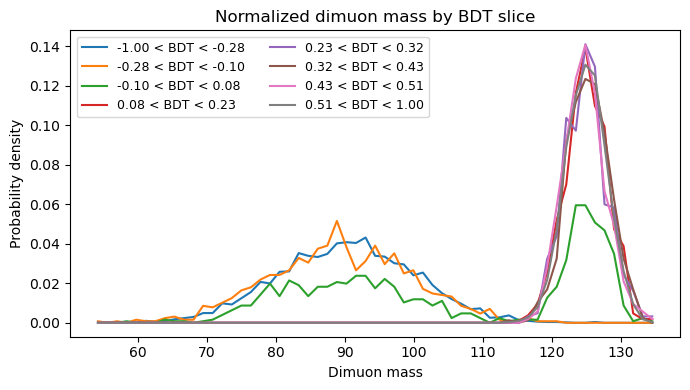

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- inputs ---
# df: pandas DataFrame with columns ["BDT_Score", "dimuon_mass"]

# BDT bin edges from your legend
bdt_edges = np.array([-1.00, -0.28, -0.10,  0.08,  0.23,  0.32,  0.43,  0.51,  1.00])

# Choose mass histogram binning (here: automatic from data range)
mmin, mmax = df["dimuon_mass"].min(), df["dimuon_mass"].max()
mass_bins = np.linspace(mmin, mmax, 60)  # ~59 bins; adjust as you like

plt.figure(figsize=(7,4))

for lo, hi in zip(bdt_edges[:-1], bdt_edges[1:]):
    # (lo, hi]: match legend style “lo < BDT < hi”
    mask = (df["BDT_Score"] > lo) & (df["BDT_Score"] <= hi)
    if not mask.any():
        continue  # skip empty slices

    # density=True => area under each curve = 1 (normalized)
    hist, bin_edges = np.histogram(df.loc[mask, "dimuon_mass"], bins=mass_bins, density=True)
    centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

    plt.plot(centers, hist, label=f"{lo:.2f} < BDT < {hi:.2f}")

plt.xlabel(r"Dimuon mass")
plt.ylabel("Probability density")
plt.title("Normalized dimuon mass by BDT slice")
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


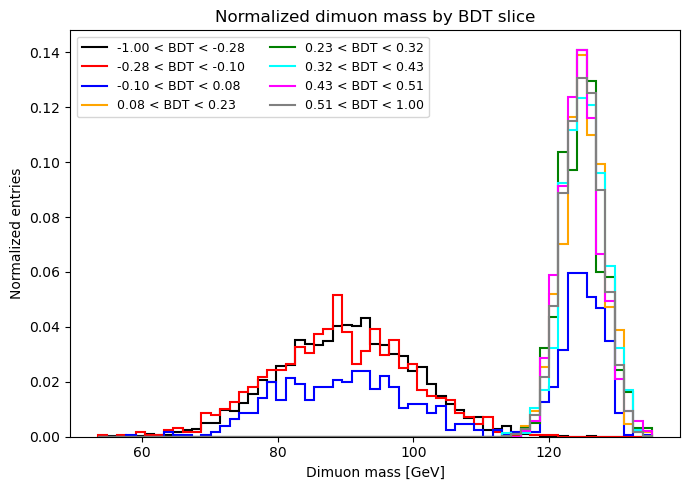

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

# --- make dummy df ---
np.random.seed(42)
bdt_scores = np.random.uniform(-1, 1, size=10000)
dimuon_mass = np.where(
    bdt_scores > 0,
    np.random.normal(125, 3, size=10000),
    np.random.normal(90, 10, size=10000),
)
df = pd.DataFrame({"BDT_Score": bdt_scores, "dimuon_mass": dimuon_mass})

# --- binning ---
bdt_edges = np.array([-1.00, -0.28, -0.10, 0.08, 0.23, 0.32, 0.43, 0.51, 1.00])
mmin, mmax = df["dimuon_mass"].min(), df["dimuon_mass"].max()
mass_bins = np.linspace(mmin, mmax, 60)

# --- plotting ---
plt.figure(figsize=(7,5))

colors = ["black","red","blue","orange","green","cyan","magenta","gray"]

for (lo, hi), color in zip(zip(bdt_edges[:-1], bdt_edges[1:]), colors):
    mask = (df["BDT_Score"] > lo) & (df["BDT_Score"] <= hi)
    if not mask.any():
        continue
    
    hist, bins = np.histogram(df.loc[mask,"dimuon_mass"], bins=mass_bins, density=True)
    
    hep.histplot(
        hist,
        bins,
        label=f"{lo:.2f} < BDT < {hi:.2f}",
        histtype="step",
        color=color,
    )

plt.xlabel(r"Dimuon mass [GeV]")
plt.ylabel("Normalized entries")
plt.title("Normalized dimuon mass by BDT slice")
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


In [15]:
import pandas as pd

# Example df
df = pd.DataFrame({
    "dataset": ["A", "B", "A", "C"],
    "wgt_nominal": [1.0, 2.0, 3.0, 4.0],
    "dimuon_ebe_mass_res": [0.5, 0.8, 2.0, 1.5]
})

# For rows where dataset == "A", divide wgt_nominal by dimuon_ebe_mass_res
mask = df["dataset"] == "A"
df.loc[mask, "wgt_nominal"] = (
    df.loc[mask, "wgt_nominal"] / df.loc[mask, "dimuon_ebe_mass_res"]
)

print(df)


  dataset  wgt_nominal  dimuon_ebe_mass_res
0       A          2.0                  0.5
1       B          2.0                  0.8
2       A          1.5                  2.0
3       C          4.0                  1.5


In [9]:
import numpy as np

def weighted_quantile(values, quantile, sample_weight=None):
    """
    Compute weighted quantile of given data.
    
    values : np.ndarray
        Data (e.g. BDT scores).
    quantile : float
        Quantile in [0, 1] (e.g. 0.3 for 30%).
    sample_weight : np.ndarray or None
        Weights (same length as values).
    """
    values = np.array(values)
    if sample_weight is None:
        sample_weight = np.ones(len(values))
    else:
        sample_weight = np.array(sample_weight)
    
    # sort by values
    sorter = np.argsort(values)
    values = values[sorter]
    weights = sample_weight[sorter]

    # compute cumulative normalized weights
    cumsum = np.cumsum(weights)
    cutoff = quantile * np.sum(weights)

    return values[np.searchsorted(cumsum, cutoff)]


In [11]:
# Example arrays
bdt = np.array([0.1, 0.4, 0.2, 0.9, 0.7])
wgt = np.array([1.0, 2.0, 0.5, 3.0, 1.5])

# Shuffle them together
idx = np.arange(len(bdt))
np.random.shuffle(idx)
bdt = bdt[idx]
wgt = wgt[idx]

# Find threshold for lowest 30% of weight
threshold = weighted_quantile(bdt, 0.3, sample_weight=wgt)
print("BDT score threshold (30% cumulative weight):", threshold)


BDT score threshold (30% cumulative weight): 0.4


/tmp/ipykernel_2259/224955551.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)  # sample 'n' distinct colors


[(np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), np.float64(1.0)), (np.float64(1.0), np.float64(0.7333333333333333), np.float64(0.47058823529411764), np.float64(1.0)), (np.float64(0.8392156862745098), np.float64(0.15294117647058825), np.float64(0.1568627450980392), np.float64(1.0)), (np.float64(0.5490196078431373), np.float64(0.33725490196078434), np.float64(0.29411764705882354), np.float64(1.0)), (np.float64(0.9686274509803922), np.float64(0.7137254901960784), np.float64(0.8235294117647058), np.float64(1.0)), (np.float64(0.7372549019607844), np.float64(0.7411764705882353), np.float64(0.13333333333333333), np.float64(1.0)), (np.float64(0.6196078431372549), np.float64(0.8549019607843137), np.float64(0.8980392156862745), np.float64(1.0))]


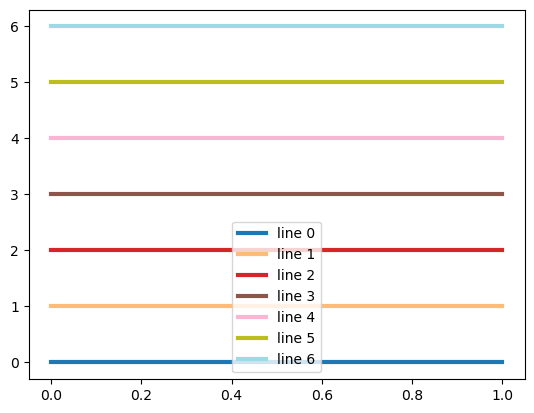

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def get_unique_colors(n, cmap_name="tab10"):
    """
    Return a list of n unique colors (as RGBA tuples) compatible with pyplot.
    
    Parameters
    ----------
    n : int
        Number of colors to generate.
    cmap_name : str, optional
        Name of a matplotlib colormap (default "tab10").
    
    Returns
    -------
    list of RGBA tuples
    """
    cmap = cm.get_cmap(cmap_name, n)  # sample 'n' distinct colors
    return [cmap(i) for i in range(n)]


# Example: get 7 unique colors
colors = get_unique_colors(7, cmap_name="tab20")
print(colors)

# Example plotting
for i, color in enumerate(colors):
    plt.plot([0, 1], [i, i], color=color, lw=3, label=f"line {i}")
plt.legend()
plt.show()


In [17]:
n_cats=16
np.linspace(-1,1,n_cats+1)


array([-1.   , -0.875, -0.75 , -0.625, -0.5  , -0.375, -0.25 , -0.125,
        0.   ,  0.125,  0.25 ,  0.375,  0.5  ,  0.625,  0.75 ,  0.875,
        1.   ])

In [23]:
import pandas as pd
import numpy as np

# Example dummy df
df = pd.DataFrame({
    "A": [1, 2, 3, 4, 5],
    "B": [5, 4, 3, 2, 1],
    "C": [2, 2, 2, 3, 3],
    "wgt": [-1.0, 2.0, -0.5, 1.5, 0.8]
})
print(df)
# Split by sign of weight
neg_df = df[df["wgt"] < 0].reset_index(drop=True)
pos_df = df[df["wgt"] > 0].reset_index(drop=True)

pairs = []

for i, neg_row in neg_df.iterrows():
    # Compute L1 norm distances to all positive rows
    diffs = np.abs(pos_df[["A", "B", "C"]] - neg_row[["A", "B", "C"]].values)
    dists = diffs.sum(axis=1)
    
    # Find index of closest positive row
    j = dists.idxmin()
    pos_row = pos_df.loc[j]
    
    pairs.append((neg_row.to_dict(), pos_row.to_dict()))

# Display results
for idx, (neg, pos) in enumerate(pairs):
    print(f"Pair {idx}:")
    print("  Negative row:", neg)
    print("  Positive row:", pos)


   A  B  C  wgt
0  1  5  2 -1.0
1  2  4  2  2.0
2  3  3  2 -0.5
3  4  2  3  1.5
4  5  1  3  0.8
Pair 0:
  Negative row: {'A': 1.0, 'B': 5.0, 'C': 2.0, 'wgt': -1.0}
  Positive row: {'A': 2.0, 'B': 4.0, 'C': 2.0, 'wgt': 2.0}
Pair 1:
  Negative row: {'A': 3.0, 'B': 3.0, 'C': 2.0, 'wgt': -0.5}
  Positive row: {'A': 2.0, 'B': 4.0, 'C': 2.0, 'wgt': 2.0}


In [20]:
import numpy as np
import pandas as pd

def pair_neg_pos_by_L1(df, cols=("A","B","C"), wgt_col="wgt"):
    """
    Pair each negative-weight row with at most one positive-weight row
    by minimizing the L1 distance over `cols` using the Hungarian algorithm.

    Returns:
        matches_df: DataFrame with columns:
          - neg_idx, pos_idx: original df indices
          - dist: L1 distance
          - columns for neg_* and pos_* values of each col in `cols`
    """
    # Split
    neg = df[df[wgt_col] < 0].copy()
    pos = df[df[wgt_col] > 0].copy()

    if len(neg) == 0 or len(pos) == 0:
        # Nothing to match
        return pd.DataFrame(columns=["neg_idx","pos_idx","dist"] + 
                            [f"neg_{c}" for c in cols] + [f"pos_{c}" for c in cols])

    # Extract arrays
    X = neg.loc[:, cols].to_numpy(dtype=float)        # shape: (n_neg, d)
    Y = pos.loc[:, cols].to_numpy(dtype=float)        # shape: (n_pos, d)

    # Build cost matrix: L1 distances between all neg/pos rows
    # cost[i, j] = sum_k |X[i,k] - Y[j,k]|
    # Broadcasting: (n_neg, 1, d) - (1, n_pos, d) -> (n_neg, n_pos, d)
    cost = np.abs(X[:, None, :] - Y[None, :, :]).sum(axis=2)

    # Solve assignment (Hungarian algorithm)
    try:
        from scipy.optimize import linear_sum_assignment
    except ImportError as e:
        raise ImportError(
            "This function requires SciPy. Install with `pip install scipy`."
        ) from e

    row_ind, col_ind = linear_sum_assignment(cost)  # works for rectangular cost matrices

    # Keep only min(len(neg), len(pos)) matches (already ensured by the solver)
    neg_idx = neg.index.to_numpy()[row_ind]
    pos_idx = pos.index.to_numpy()[col_ind]
    dists   = cost[row_ind, col_ind]

    # Build an informative result table
    data = {
        "neg_idx": neg_idx,
        "pos_idx": pos_idx,
        "dist": dists,
    }
    for c in cols:
        data[f"neg_{c}"] = df.loc[neg_idx, c].to_numpy()
        data[f"pos_{c}"] = df.loc[pos_idx, c].to_numpy()

    matches_df = pd.DataFrame(data).sort_values("dist").reset_index(drop=True)
    return matches_df

# --- Minimal example ---
if __name__ == "__main__":
    df = pd.DataFrame({
        "A": [1, 2, 3, 4, 5, 6],
        "B": [5, 4, 3, 2, 1, 0],
        "C": [2, 2, 2, 3, 3, 3],
        "wgt": [-1.0, 2.0, -0.5, 1.5, 0.8, 0.3]
    })
    print(df)
    matches = pair_neg_pos_by_L1(df, cols=("A","B","C"), wgt_col="wgt")
    print(matches)


   A  B  C  wgt
0  1  5  2 -1.0
1  2  4  2  2.0
2  3  3  2 -0.5
3  4  2  3  1.5
4  5  1  3  0.8
5  6  0  3  0.3
   neg_idx  pos_idx  dist  neg_A  pos_A  neg_B  pos_B  neg_C  pos_C
0        0        1   2.0      1      2      5      4      2      2
1        2        3   3.0      3      4      3      2      2      3


In [29]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

def pair_and_remove(df, cols=("A","B","C"), wgt_col="wgt"):
    """
    Pair each negative-weight row with at most one positive-weight row
    using Hungarian algorithm (minimizing L1 distance).
    Remove the paired rows from the original df.

    Returns:
        matches_df: DataFrame with match info (neg_idx, pos_idx, dist, ...)
        remaining_df: df with matched rows removed
    """
    # Split
    neg = df[df[wgt_col] < 0].copy()
    pos = df[df[wgt_col] > 0].copy()

    if len(neg) == 0 or len(pos) == 0:
        return pd.DataFrame(), df.copy()

    # Arrays
    X = neg.loc[:, cols].to_numpy(dtype=float)
    Y = pos.loc[:, cols].to_numpy(dtype=float)
    print(f"X: {X}")
    print(f"y: {Y}")
    # Cost matrix (L1 distance)
    cost = np.abs(X[:, None, :] - Y[None, :, :]).sum(axis=2)
    print(f"cost: {cost}")
    
    # Hungarian assignment
    row_ind, col_ind = linear_sum_assignment(cost)
    print(f"row_ind: {row_ind}")
    print(f"col_ind: {col_ind}")
    
    # Map back to indices
    neg_idx = neg.index.to_numpy()[row_ind]
    pos_idx = pos.index.to_numpy()[col_ind]
    dists   = cost[row_ind, col_ind]

    # Matches dataframe
    data = {
        "neg_idx": neg_idx,
        "pos_idx": pos_idx,
        "dist": dists,
        "neg_wgt": df.loc[neg_idx, wgt_col].to_numpy(),
        "pos_wgt": df.loc[pos_idx, wgt_col].to_numpy(),
    }
    for c in cols:
        data[f"neg_{c}"] = df.loc[neg_idx, c].to_numpy()
        data[f"pos_{c}"] = df.loc[pos_idx, c].to_numpy()

    matches_df = pd.DataFrame(data).sort_values("dist").reset_index(drop=True)

    # Drop matched rows from original df
    matched_indices = np.concatenate([neg_idx, pos_idx])
    remaining_df = df.drop(index=matched_indices).reset_index(drop=True)

    return matches_df, remaining_df


# --- Example ---
if __name__ == "__main__":
    df = pd.DataFrame({
        "A": [1, 2, 3, 4, 5, 6],
        "B": [5, 4, 3, 2, 1, 0],
        "C": [2, 2, 2, 3, 3, 3],
        "wgt": [-1.0, 2.0, -0.5, 1.5, 0.8, 0.3]
    })
    print(df)
    
    matches, remaining = pair_and_remove(df)
    print("Matches:")
    print(matches)
    print("\nRemaining df:")
    print(remaining)


   A  B  C  wgt
0  1  5  2 -1.0
1  2  4  2  2.0
2  3  3  2 -0.5
3  4  2  3  1.5
4  5  1  3  0.8
5  6  0  3  0.3
X: [[1. 5. 2.]
 [3. 3. 2.]]
y: [[2. 4. 2.]
 [4. 2. 3.]
 [5. 1. 3.]
 [6. 0. 3.]]
cost: [[ 2.  7.  9. 11.]
 [ 2.  3.  5.  7.]]
row_ind: [0 1]
col_ind: [0 1]
Matches:
   neg_idx  pos_idx  dist  neg_wgt  pos_wgt  neg_A  pos_A  neg_B  pos_B  \
0        0        1   2.0     -1.0      2.0      1      2      5      4   
1        2        3   3.0     -0.5      1.5      3      4      3      2   

   neg_C  pos_C  
0      2      2  
1      2      3  

Remaining df:
   A  B  C  wgt
0  5  1  3  0.8
1  6  0  3  0.3


In [28]:
abs(np.array([1., 5., 2.])-np.array([2., 4., 2.])).sum()

np.float64(2.0)

In [2]:
import pandas as pd

# Example DataFrame
df = pd.DataFrame({
    "dataset": ["ggH", "DY", "VBF", "TTbar"],
    "wgt_nominal_orig": [1.2, 3.4, 2.5, 4.1],
    "bdt_wgt": [0.5, 0.8, 0.6, 0.9]
})

# List of signal datasets
sig_datasets = ["ggH", "VBF"]

# Overwrite bdt_wgt with wgt_nominal_orig if dataset is in sig_datasets
df.loc[df["dataset"].isin(sig_datasets), "bdt_wgt"] = df["wgt_nominal_orig"]

print(df)


  dataset  wgt_nominal_orig  bdt_wgt
0     ggH               1.2      1.2
1      DY               3.4      0.8
2     VBF               2.5      2.5
3   TTbar               4.1      0.9


In [3]:
import pandas as pd

# Example DataFrame
df = pd.DataFrame({
    "dataset": ["ggH", "DY", "VBF", "TTbar"],
    "wgt_nominal_orig": [1.2, 3.4, 2.5, 4.1],
    "bdt_wgt": [0.5, 0.8, 0.6, 0.9]
})

# List of signal datasets
sig_datasets = ["ggH", "VBF"]

# Overwrite bdt_wgt for signals with wgt_nominal_orig
df.loc[df["dataset"].isin(sig_datasets), "bdt_wgt"] = df["wgt_nominal_orig"]

# Normalize only signal rows so that their sum = 1
mask = df["dataset"].isin(sig_datasets)
df.loc[mask, "bdt_wgt"] = df.loc[mask, "bdt_wgt"] / df.loc[mask, "bdt_wgt"].sum()

print(df)


  dataset  wgt_nominal_orig   bdt_wgt
0     ggH               1.2  0.324324
1      DY               3.4  0.800000
2     VBF               2.5  0.675676
3   TTbar               4.1  0.900000


In [6]:
import pandas as pd

# Example df
df = pd.DataFrame({
    "dataset": ["ggH", "ggH", "VBF", "DY", "DY", "TTbar"],
    "value": [1, 2, 3, 4, 5, 6]
})

# Make an empty copy of df (same columns, no rows)
df_out = df.iloc[0:0].copy()
print(df_out)
# Iterate over unique datasets
for ds in df["dataset"].unique():
    # Select rows matching this dataset
    subset = df[df["dataset"] == ds].copy()

    # --- Preprocess here ---
    # Example: double the 'value' column for signal datasets
    if ds in ["ggH", "VBF"]:
        subset["value"] *= 2

    # Append processed rows into the output df
    df_out = pd.concat([df_out, subset], ignore_index=True)

print(df)
print(df_out)


Empty DataFrame
Columns: [dataset, value]
Index: []
  dataset  value
0     ggH      1
1     ggH      2
2     VBF      3
3      DY      4
4      DY      5
5   TTbar      6
  dataset  value
0     ggH      2
1     ggH      4
2     VBF      6
3      DY      4
4      DY      5
5   TTbar      6


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Dummy df for demonstration ---
np.random.seed(42)
df = pd.DataFrame({
    "dimuon_mass": np.random.uniform(110, 140, 1000),
    "bdt_wgt": np.random.exponential(scale=1.0, size=1000),
    "dataset": np.random.choice(["ggH", "VBF", "DY"], size=1000)
})

# --- Mass window cut ---
mass_mask = (df["dimuon_mass"] > 115) & (df["dimuon_mass"] < 135)
df_sel = df[mass_mask]

# ===================================================
# 1) Overlay all datasets in a single plot
# ===================================================
plt.figure(figsize=(6,4))

for dataset in df_sel["dataset"].unique():
    subset = df_sel[df_sel["dataset"] == dataset]
    plt.hist(
        subset["bdt_wgt"],
        bins=30,
        histtype="step",
        label=dataset
    )

plt.xlabel("bdt_wgt")
plt.ylabel("Counts")
plt.title("bdt_wgt distribution per dataset\n$115 < m_{\mu\mu} < 135$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ===================================================
# 2) One separate figure per dataset
# ===================================================
for dataset in df_sel["dataset"].unique():
    subset = df_sel[df_sel["dataset"] == dataset]
    plt.figure(figsize=(6,4))
    plt.hist(
        subset["bdt_wgt"],
        bins=30,
        histtype="step",
        color="blue",
        label=dataset
        
    )
    plt.xlabel("bdt_wgt")
    plt.ylabel("Counts")
    plt.title(f"bdt_wgt distribution for {dataset}\n$115 < m_{{\mu\mu}} < 135$")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


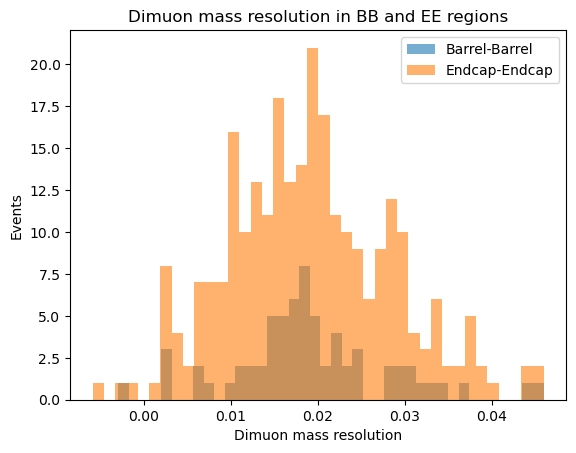

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Dummy dataframe for demonstration ---
np.random.seed(0)
df = pd.DataFrame({
    "dimuon_mass_res": np.random.normal(0.02, 0.01, 1000),
    "mu1_eta": np.random.uniform(-2.5, 2.5, 1000),
    "mu2_eta": np.random.uniform(-2.5, 2.5, 1000),
})

# --- Define regions ---
barrel_cut = 0.9  # threshold for barrel 
endcap_cut_low = 1.8  # threshold for endcap
endcap_cut_high = 2.4  # threshold for endcap

barrel_barrel = df[(df["mu1_eta"].abs() < barrel_cut) & (df["mu2_eta"].abs() < barrel_cut)]
barrel_barrel = df[
    (endcap_cut_low < df["mu1_eta"].abs()) &  (df["mu1_eta"].abs()  < endcap_cut_high) & 
                    (endcap_cut_low < df["mu2_eta"].abs()) & (df["mu2_eta"].abs() < endcap_cut_high)
     ]

# --- Plot histograms ---
plt.hist(barrel_barrel["dimuon_mass_res"], bins=40, alpha=0.6, label="Barrel-Barrel")
plt.hist(endcap_endcap["dimuon_mass_res"], bins=40, alpha=0.6, label="Endcap-Endcap")

plt.xlabel("Dimuon mass resolution")
plt.ylabel("Events")
plt.legend()
plt.title("Dimuon mass resolution in BB and EE regions")
plt.show()


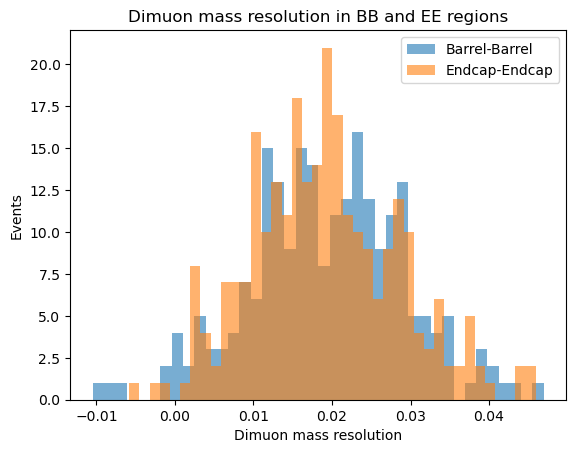

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Dummy dataframe for demonstration ---
np.random.seed(0)
df = pd.DataFrame({
    "dimuon_mass_res": np.random.normal(0.02, 0.01, 1000),
    "mu1_eta": np.random.uniform(-2.5, 2.5, 1000),
    "mu2_eta": np.random.uniform(-2.5, 2.5, 1000),
})

# --- Define regions ---
barrel_cut = 1.2  # threshold for barrel vs endcap

barrel_barrel = df[(df["mu1_eta"].abs() < barrel_cut) & (df["mu2_eta"].abs() < barrel_cut)]
endcap_endcap = df[(df["mu1_eta"].abs() > barrel_cut) & (df["mu2_eta"].abs() > barrel_cut)]

# --- Plot histograms ---
plt.hist(barrel_barrel["dimuon_mass_res"], bins=40, alpha=0.6, label="Barrel-Barrel")
plt.hist(endcap_endcap["dimuon_mass_res"], bins=40, alpha=0.6, label="Endcap-Endcap")

plt.xlabel("Dimuon mass resolution")
plt.ylabel("Events")
plt.legend()
plt.title("Dimuon mass resolution in BB and EE regions")
plt.show()


In [21]:
import pandas as pd

# Example dataframe
df = pd.DataFrame({
    "dataset": ["vbf", "ggh", "DY", "ttH", "ZH", "other"],
    "value": [10, 20, 30, 40, 50, 60]
})

# Keep only rows where dataset is in ["vbf", "ggh", "DY"]
keep_vals = ["vbf", "ggh", "DY"]
df_filtered = df[df["dataset"].isin(keep_vals)]

print(df_filtered)


  dataset  value
0     vbf     10
1     ggh     20
2      DY     30


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Example DataFrame ---
np.random.seed(42)
df = pd.DataFrame({
    "dimuon_pt": np.random.exponential(scale=50, size=1000),
    "dimuon_rap": np.random.normal(loc=0, scale=1, size=1000)
})

# --- 2D histogram (heatmap) ---
plt.figure(figsize=(6,5))
plt.hist2d(
    df["dimuon_pt"], df["dimuon_rap"],
    bins=(50, 50),       # number of bins in x and y
    cmap="viridis"       # colormap
)
plt.colorbar(label="Counts")
plt.xlabel("dimuon_pt")
plt.ylabel("dimuon_rap")
plt.title("2D Histogram Heatmap of dimuon_pt vs dimuon_rap")
plt.show()


In [25]:
import awkward as ak
import pandas as pd
import numpy as np

# --- 1) Example awkward "record zip" (flat records) ---
arr = ak.zip(
    {
        "A": [1, 2, 3],
        "B": [10.0, 20.5, None],   # None -> option type
        "wgt": [1.0, -0.5, 2.0],
    },
    with_name="MyRecord"  # optional
)

# --- 2) To pandas DataFrame ---
# For flat records, this is a simple 1-row-index DataFrame.
df = ak.to_dataframe(arr).reset_index(drop=True)

# --- 3) Do your pandas processing as usual ---
# (examples)
df["B_filled"] = df["B"].fillna(0.0)
df["sum_AB"]   = df["A"] + df["B_filled"]
df             = df[df["wgt"] > 0].reset_index(drop=True)

# # --- 4A) Back to awkward via from_pandas (simple + preserves None masks) ---
# arr_back = ak.from_pandas(df)  # returns a flat record array again

# --- 4B) OR back to awkward via ak.zip (explicit control of fields) ---
# This is handy when you want to pick/select/rename columns explicitly.
arr_back_zip = ak.zip(
    {col: ak.Array(df[col].to_numpy()) for col in df.columns}
)


In [26]:
arr_back_zip

<Array [{A: 1, B: 10, wgt: 1, ...}, {...}] type='2 * {A: int64, B: float64,...'>

In [27]:
arr

<Array [{A: 1, B: 10, wgt: 1}, ..., {...}] type='3 * MyRecord[A: int64, B: ...'>

In [1]:
import ROOT as rt
import numpy as np

# Ensure histograms store sum of squares of weights for error calculation
rt.TH1.SetDefaultSumw2(True)

def hist_stddev_with_unc(counts: np.ndarray, edges: np.ndarray):
    """
    Compute std deviation and its uncertainty using ROOT's TH1D.

    Parameters
    ----------
    counts : np.ndarray
        Histogram bin contents (like from np.histogram).
    edges : np.ndarray
        Histogram bin edges (len = len(counts)+1).

    Returns
    -------
    std : float
        Standard deviation of the histogram (RMS).
    std_err : float
        Uncertainty on the standard deviation.
    """
    nbins = len(counts)
    h = rt.TH1D("h_tmp", "temporary hist", nbins, edges)

    for i, c in enumerate(counts, start=1):  # ROOT bins start at 1
        h.SetBinContent(i, float(c))

    std     = h.GetStdDev()
    std_err = h.GetStdDevError()
    return std, std_err


# --- Example usage ---
if __name__ == "__main__":
    data = np.random.normal(loc=0, scale=1, size=10000)
    counts, edges = np.histogram(data, bins=30, range=(-5,5))

    std, std_err = hist_stddev_with_unc(counts, edges)
    print(f"StdDev = {std:.4f} ± {std_err:.4f}")


StdDev = 1.0050 ± 0.0071


In [3]:
import numpy as np

# Example bin edges (length = nbins+1)
edges = np.array([0, 1, 2, 3, 4, 5, 6])

# Merge bins: keep every 2nd edge
merged_edges = edges[::4]

# Make sure the last edge is included
if edges[-1] != merged_edges[-1]:
    merged_edges = np.append(merged_edges, edges[-1])

print("Original edges:", edges)
print("Merged edges:", merged_edges)


Original edges: [0 1 2 3 4 5 6]
Merged edges: [0 4 6]


In [8]:
import pandas as pd

# Example df
df = pd.DataFrame({
    "BDT cat": ["cat0", "cat0", "cat1", "cat1"],
    "fit function": ["poly1", "poly2", "poly1", "poly2"],
    "chi2ndf": [1.2, 1.5, 0.9, 1.1]
})

print("Original df:\n", df)

# Pivot version
df_pivot = df.pivot(index="BDT cat", columns="fit function", values="chi2ndf")
print("\nPivoted df:\n", df_pivot)

# If you want to keep 'fit function' as normal columns (not multi-index)
df_pivot = df_pivot.reset_index()
print("\nReset index version:\n", df_pivot)


Original df:
   BDT cat fit function  chi2ndf
0    cat0        poly1      1.2
1    cat0        poly2      1.5
2    cat1        poly1      0.9
3    cat1        poly2      1.1

Pivoted df:
 fit function  poly1  poly2
BDT cat                   
cat0            1.2    1.5
cat1            0.9    1.1

Reset index version:
 fit function BDT cat  poly1  poly2
0               cat0    1.2    1.5
1               cat1    0.9    1.1


In [7]:
import pandas as pd

df = pd.read_csv("/work/users/yun79/Run3/copperheadV2/validation/ggH/categorization/plots/fullRun_Jun23_2025_1n2Revised_x_V2_Aug28_PosWgtRun0p7_MassResRun1_ggh/all_signal/Fig6_13.csv")

In [8]:
df["sig_hist"]

0     0.001861
1     0.004827
2     0.007942
3     0.011387
4     0.015070
5     0.018527
6     0.021768
7     0.024180
8     0.025734
9     0.027981
10    0.030665
11    0.033220
12    0.035614
13    0.037947
14    0.040139
15    0.041744
16    0.043623
17    0.045484
18    0.045941
19    0.045244
20    0.044460
21    0.043292
22    0.042123
23    0.040636
24    0.038552
25    0.034997
26    0.030910
27    0.027255
28    0.024105
29    0.020709
30    0.017064
31    0.014493
32    0.013059
33    0.011769
34    0.010499
35    0.008949
36    0.007204
37    0.005483
38    0.003696
39    0.001847
Name: sig_hist, dtype: float64

In [6]:
df["binning"]

'[-9.00000000e-01 -8.55000000e-01 -8.10000000e-01 -7.65000000e-01\n -7.20000000e-01 -6.75000000e-01 -6.30000000e-01 -5.85000000e-01\n -5.40000000e-01 -4.95000000e-01 -4.50000000e-01 -4.05000000e-01\n -3.60000000e-01 -3.15000000e-01 -2.70000000e-01 -2.25000000e-01\n -1.80000000e-01 -1.35000000e-01 -9.00000000e-02 -4.50000000e-02\n -1.11022302e-16  4.50000000e-02  9.00000000e-02  1.35000000e-01\n  1.80000000e-01  2.25000000e-01  2.70000000e-01  3.15000000e-01\n  3.60000000e-01  4.05000000e-01  4.50000000e-01  4.95000000e-01\n  5.40000000e-01  5.85000000e-01  6.30000000e-01  6.75000000e-01\n  7.20000000e-01  7.65000000e-01  8.10000000e-01  8.55000000e-01\n  9.00000000e-01]'

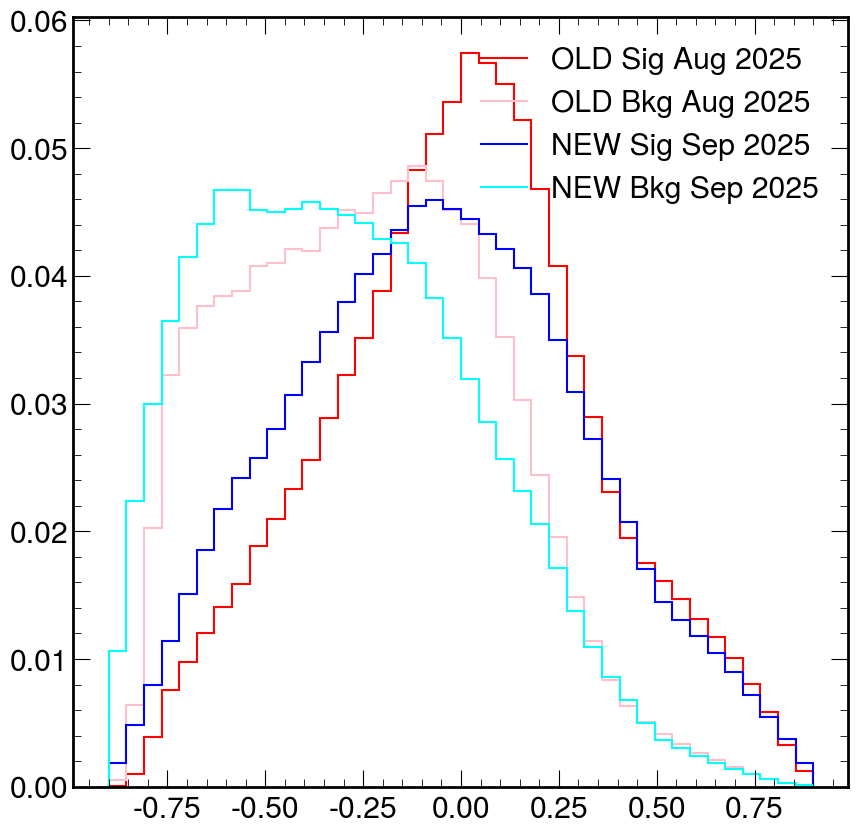

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import mplhep as hep

# Paths
OLD = "/work/users/yun79/Run3/copperheadV2/validation/ggH/categorization/plots/fullRun_Jun23_2025_1n2Revised_x_V2_fullRun_Jun21_2025_1n2Revised_ggh_w_allYearBDT_w_newBDTTargetYields/all_signal/"
NEW = "/work/users/yun79/Run3/copperheadV2/validation/ggH/categorization/plots/fullRun_Jun23_2025_1n2Revised_x_V2_Aug28_PosWgtRun0p7_MassResRun1_ggh/all_signal"

# Read histograms
old_df = pd.read_csv(os.path.join(OLD, "Fig6_13.csv"))
new_df = pd.read_csv(os.path.join(NEW, "Fig6_13.csv"))

old_binning = pd.read_csv(os.path.join(OLD, "Fig6_13Binning.csv"))["binning"].values
new_binning = pd.read_csv(os.path.join(NEW, "Fig6_13Binning.csv"))["binning"].values

plt.style.use(hep.style.CMS)
fig, ax_main = plt.subplots()

hep.histplot(
    old_df["sig_hist"].values, 
    xerr=True, 
    bins=old_binning, 
    stack=False, 
    histtype='step', 
    # color='blue', 
    color='red', 
    label='OLD Sig Aug 2025', 
    ax=ax_main,
)
hep.histplot(
    old_df["bkg_hist"].values, 
    xerr=True, 
    bins=old_binning, 
    stack=False, 
    histtype='step', 
    # color='red', 
    color='pink', 
    label='OLD Bkg Aug 2025', 
    ax=ax_main,
)
hep.histplot(
    new_df["sig_hist"].values, 
    xerr=True, 
    bins=new_binning, 
    stack=False, 
    histtype='step', 
    # color='cyan', 
    color='blue', 
    label='NEW Sig Sep 2025', 
    ax=ax_main,
)
hep.histplot(
    new_df["bkg_hist"].values, 
    xerr=True, 
    bins=new_binning, 
    stack=False, 
    histtype='step', 
    # color='pink', 
    color='cyan', 
    label='NEW Bkg Sep 2025', 
    ax=ax_main,
)
ax_main.legend(loc="best")
# plt.show()
plt.savefig("6_13Comparison.pdf")

In [2]:
import numpy as np

# A = np.array([0,0.21, 0.54, 0.78, 0.93, 0.98, 1.0])
# A = np.array([0,0.21, 0.54, 0.78, 0.93, 1.0])
# A = np.array([0,0.22, 0.51, 0.92, 0.98, 1.0])
# A = np.array([0,0.25, 0.58, 0.93, 0.98, 1.0])
# A = np.array([0,0.21, 0.53, 0.78 ,0.93, 1.0])
# A = np.array([0, 0.21, 0.54, 0.92, 0.98, 1.0])
A = np.array([0, 0.25, 0.58, 0.78, 0.92, 1.0])
# 0.21 0.54 0.92 0.98
np.diff(A)


array([0.25, 0.33, 0.2 , 0.14, 0.08])

In [13]:
np.diff(A).sum()


np.float64(1.0)

In [ ]:
V2_Aug16_2025DefaultFillNoneBackFix_AnnhilateNegWgts_IssueNum2_ggh